In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap joblib


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("credit_risk_dataset.csv")

In [4]:
df.head(10)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3


In [5]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [6]:
df.shape


(32581, 12)

In [7]:
df['person_emp_length'].value_counts()


,count
person_emp_length,
0.0,4105
2.0,3849
3.0,3456
5.0,2946
1.0,2915
4.0,2874
6.0,2666
7.0,2196
8.0,1687


Text(0, 0.5, 'Count')

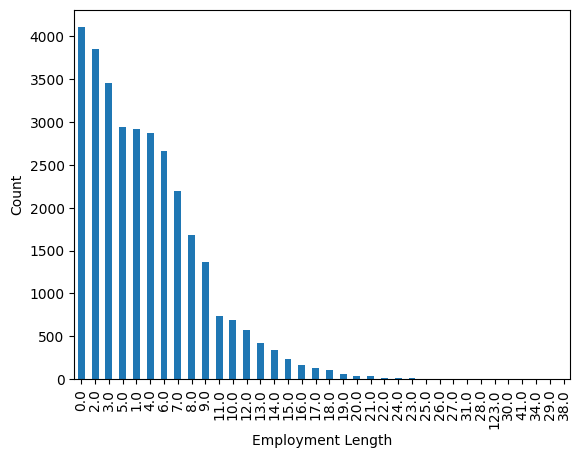

In [8]:
df['person_emp_length'].unique()
df['person_emp_length'].value_counts().plot(kind='bar')
plt.xlabel('Employment Length')
plt.ylabel('Count')

In [9]:
df['loan_int_rate'].describe()


,loan_int_rate
count,29465.000000
mean,11.011695
std,3.240459
min,5.420000
25%,7.900000
50%,10.990000
75%,13.470000
max,23.220000


In [10]:
df['loan_int_rate'].value_counts()
df['loan_int_rate'].nunique()

348

<Axes: xlabel='loan_int_rate'>

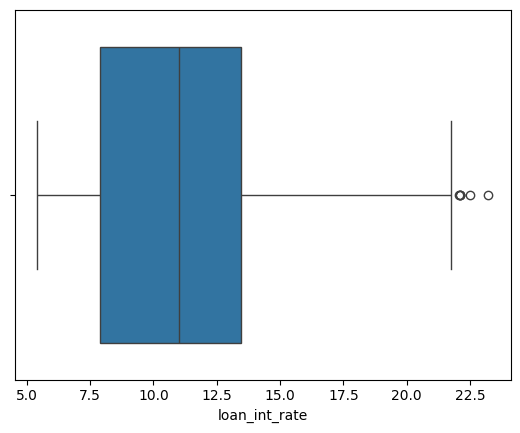

In [11]:
# df['loan_int_rate'].value_counts().plot(kind='bar') it wont workout see the reason
# plt.xlabel('Loan Interest Rate')
# plt.ylabel('Count')
# plt.show()
# # plt.figure(figsize=(20, 506))
# Quick Rule for EDA
# What you have	What you want to know	Plot
# One numerical column	Distribution	Histogram
# One numerical column	Outliers	Boxplot
# One categorical column	Counts	Bar chart
# Two numerical columns	Relationship	Scatter plot

sns.boxplot(x=df['loan_int_rate'])



<Axes: ylabel='Count'>

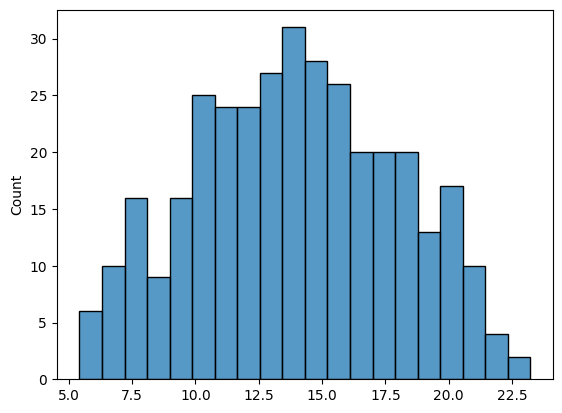

In [12]:
sns.histplot(df['loan_int_rate'].unique(),bins=20)


In [13]:
(df['loan_int_rate']>20).sum()


np.int64(74)

In [14]:
(df['loan_int_rate']>20).mean()*100

np.float64(0.22712623921917682)

In [15]:
# about 0.23% people get interest rate above 20%

In [16]:
df[(df['loan_int_rate']>20) & (df['person_emp_length'].isna())]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
2897,22,35000,MORTGAGE,NaN,VENTURE,F,5000,21.36,0,0.14,Y,2


In [17]:
df.drop(2897,inplace=True)

In [18]:
df.shape

(32580, 12)

In [19]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [20]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,894
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [21]:
((df['loan_int_rate'].isna()) & (df['person_emp_length'].isna())).sum()

np.int64(68)

In [22]:
df = df[~((df['loan_int_rate'].isna()) & (df['person_emp_length'].isna()))]

In [23]:
df.shape

(32512, 12)

In [24]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,826
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3048
loan_status,0
loan_percent_income,0


In [25]:
df['person_emp_length'].describe()

,person_emp_length
count,31686.000000
mean,4.789686
std,4.142630
min,0.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,123.000000


<Axes: xlabel='person_emp_length'>

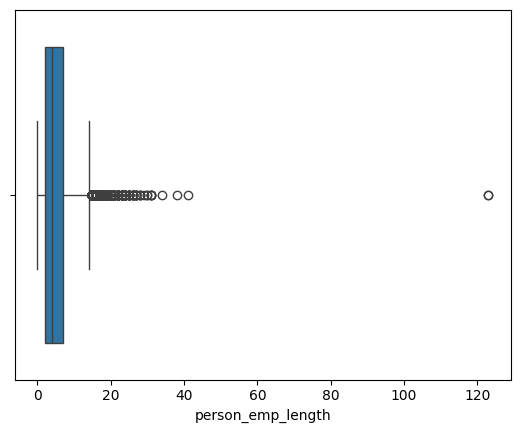

In [26]:
sns.boxplot(x=df['person_emp_length'])

In [27]:
(df['person_emp_length']>20).sum()

np.int64(111)

In [28]:
((df['person_emp_length']>20) & (df['loan_int_rate'].isna())).sum()

np.int64(11)

In [29]:
df = df[~((df['person_emp_length']>20) & (df['loan_int_rate'].isna()))]

In [30]:
df.shape

(32501, 12)

In [31]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,826
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3037
loan_status,0
loan_percent_income,0


In [32]:
((df['person_emp_length']>20) & (df['loan_int_rate']>20)).sum()

np.int64(0)

In [33]:
((df['person_emp_length'].isna()) & (df['loan_int_rate']>20)).sum()

np.int64(0)

In [34]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [35]:
df['loan_amnt'].value_counts().unique()
df['loan_amnt'].nunique()

753

In [36]:
df['cb_person_cred_hist_length'].describe()

,cb_person_cred_hist_length
count,32501.000000
mean,5.801083
std,4.051830
min,2.000000
25%,3.000000
50%,4.000000
75%,8.000000
max,30.000000


In [37]:
(df['loan_int_rate'].isna()) & (df['loan_percent_income']>20)

,0
0,False
1,False
2,False
3,False
4,False
...,...
32576,False
32577,False
32578,False
32579,False


In [38]:
df.shape

(32501, 12)

In [39]:
df['loan_status'].value_counts()

,count
loan_status,
0,25415
1,7086


In [40]:
df['loan_status'].value_counts(normalize=True)*100

,proportion
loan_status,
0,78.197594
1,21.802406


In [41]:
df.groupby('loan_status').mean(numeric_only=True)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
loan_status,,,,,,,
0,27.803738,70833.061460,4.961529,9239.974425,10.435524,0.148769,5.833956
1,27.472340,49197.033023,4.134359,10866.645498,13.060207,0.246919,5.683178


# inference
-  from the above Defaulters earn less
- Defaulters have higher  interest rate
- Defaulters take larger loans.
- Defaulters have a higher loan-to-income ratio

<Axes: xlabel='loan_status', ylabel='loan_percent_income'>

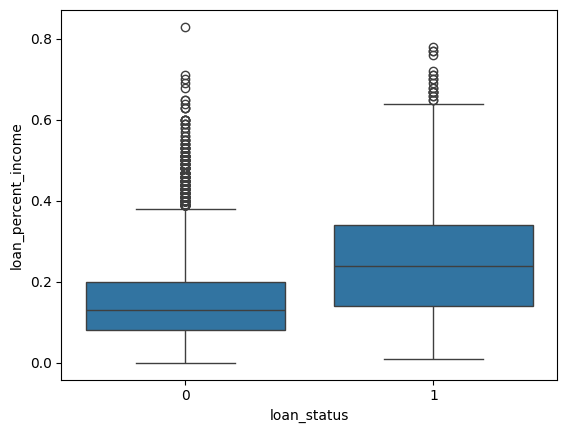

In [42]:
sns.boxplot(x='loan_status',y='loan_percent_income',data=df)

<Axes: xlabel='loan_status', ylabel='loan_int_rate'>

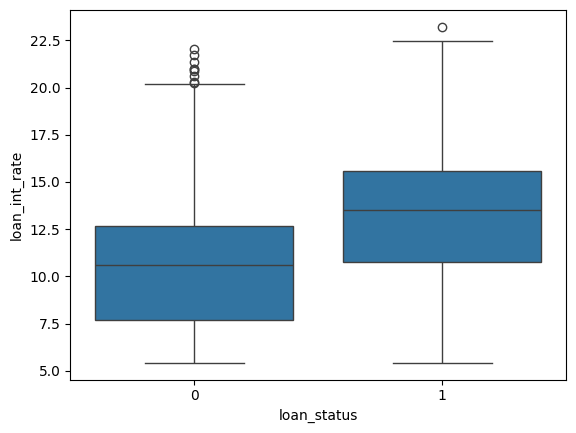

In [43]:
sns.boxplot(x='loan_status',y='loan_int_rate',data=df)

<Axes: xlabel='loan_status', ylabel='person_income'>

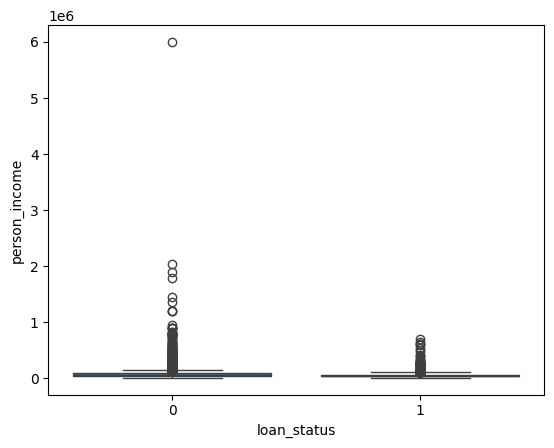

In [44]:
sns.boxplot(x='loan_status',y='person_income',data=df)

In [45]:
df['person_home_ownership'].value_counts()

,count
person_home_ownership,
RENT,16416
MORTGAGE,13406
OWN,2572
OTHER,107


In [46]:
pd.crosstab(df['person_home_ownership'], df['loan_status'], normalize='index') * 100

loan_status,0,1
person_home_ownership,,
MORTGAGE,87.445920,12.554080
OTHER,69.158879,30.841121
OWN,92.612753,7.387247
RENT,68.445419,31.554581


In [47]:
# RENT owner tend to default

In [48]:
pd.crosstab(df['loan_intent'], df['loan_status'], normalize='index') * 100

loan_status,0,1
loan_intent,,
DEBTCONSOLIDATION,71.403846,28.596154
EDUCATION,82.826087,17.173913
HOMEIMPROVEMENT,73.923910,26.076090
MEDICAL,73.339941,26.660059
PERSONAL,80.123547,19.876453
VENTURE,85.163101,14.836899


In [49]:
# loan with DEBTCONSOLIDATION has more defaulter

In [50]:
pd.crosstab(df['loan_grade'], df['loan_status'], normalize='index') * 100

loan_status,0,1
loan_grade,,
A,90.092187,9.907813
B,83.721823,16.278177
C,79.311414,20.688586
D,40.971839,59.028161
E,35.617861,64.382139
F,29.166667,70.833333
G,1.562500,98.437500


In [51]:
# lower the grade more defaulters

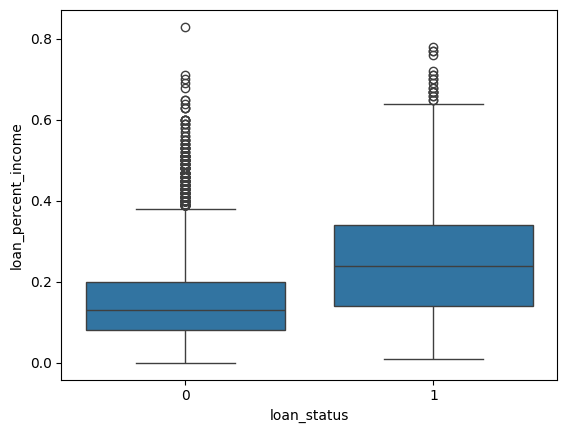

In [52]:
sns.boxplot(x='loan_status', y='loan_percent_income', data=df)
plt.show()

In [53]:
df['loan_grade'].value_counts()

,count
loan_grade,
A,10739
B,10425
C,6448
D,3622
E,963
F,240
G,64


In [54]:
df['person_home_ownership'].value_counts()

,count
person_home_ownership,
RENT,16416
MORTGAGE,13406
OWN,2572
OTHER,107


In [55]:
df['person_income'].value_counts()

,count
person_income,
60000,1044
30000,843
50000,778
40000,656
45000,590
...,...
78413,1
78420,1
72644,1


In [56]:
pd.crosstab(df['person_income'], df['loan_amnt'], normalize='index') * 100

loan_amnt,500,700,725,750,800,900,950,1000,1050,1075,...,31825,32000,32400,32500,33000,33250,33950,34000,34800,35000
person_income,,,,,,,,,,,,,,,,,,,,,
4000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4080,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4200,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4800,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4888,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1440000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1782000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1900000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [57]:
df['loan_amnt'].describe()

,loan_amnt
count,32501.000000
mean,9594.627858
std,6323.192142
min,500.000000
25%,5000.000000
50%,8000.000000
75%,12250.000000
max,35000.000000


In [58]:
pd.crosstab(df['person_income'],df['loan_percent_income'],normalize='index')*100

loan_percent_income,0.00,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,...,0.67,0.68,0.69,0.70,0.71,0.72,0.76,0.77,0.78,0.83
person_income,,,,,,,,,,,,,,,,,,,,,
4000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4080,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4200,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4800,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4888,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1440000,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1782000,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1900000,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [59]:
df['loan_percent_income'].describe()

,loan_percent_income
count,32501.000000
mean,0.170168
std,0.106743
min,0.000000
25%,0.090000
50%,0.150000
75%,0.230000
max,0.830000


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32501 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32501 non-null  int64  
 1   person_income               32501 non-null  int64  
 2   person_home_ownership       32501 non-null  object 
 3   person_emp_length           31675 non-null  float64
 4   loan_intent                 32501 non-null  object 
 5   loan_grade                  32501 non-null  object 
 6   loan_amnt                   32501 non-null  int64  
 7   loan_int_rate               29464 non-null  float64
 8   loan_status                 32501 non-null  int64  
 9   loan_percent_income         32501 non-null  float64
 10  cb_person_default_on_file   32501 non-null  object 
 11  cb_person_cred_hist_length  32501 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.2+ MB


In [61]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,826
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3037
loan_status,0
loan_percent_income,0


In [62]:
pd.crosstab(df['person_income'],df['loan_int_rate'],normalize='index')*100


loan_int_rate,5.42,5.79,5.99,6.00,6.03,6.17,6.39,6.54,6.62,6.76,...,21.14,21.21,21.27,21.36,21.64,21.74,22.06,22.11,22.48,23.22
person_income,,,,,,,,,,,,,,,,,,,,,
4000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4080,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4200,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4800,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1362000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1440000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1782000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [63]:
df.groupby(df['person_emp_length'].isna())['loan_status'].mean() * 100

,loan_status
person_emp_length,
False,21.546961
True,31.598063


In [64]:
df.groupby(df['loan_int_rate'].isna())['loan_status'].mean() * 100

,loan_status
loan_int_rate,
False,21.938637
True,20.480738


In [65]:
df.groupby(df['person_emp_length'].isna())['loan_status'].mean()*100

,loan_status
person_emp_length,
False,21.546961
True,31.598063


In [66]:
# people with missing emp_length tend to be more defaulter

In [67]:
# Create missing indicator
df['person_emp_length_missing'] = df['person_emp_length'].isna().astype(int)

# Fill missing values with median
df['person_emp_length'] = df['person_emp_length'].fillna(
    df['person_emp_length'].median()
)

In [68]:
# Fill missing interest rates using median within each loan grade
df['loan_int_rate'] = df.groupby('loan_grade')['loan_int_rate'].transform(
    lambda x: x.fillna(x.median())
)

In [69]:
df[['person_emp_length', 'loan_int_rate']].isnull().sum()

,0
person_emp_length,0
loan_int_rate,0


In [70]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


In [71]:
df['person_age'].describe()

,person_age
count,32501.000000
mean,27.731485
std,6.346632
min,20.000000
25%,23.000000
50%,26.000000
75%,30.000000
max,144.000000


In [72]:
(df['person_age']>100).sum()

np.int64(5)

In [73]:
df['person_income'].describe()

,person_income
count,3.250100e+04
mean,6.611589e+04
std,6.202142e+04
min,4.000000e+03
25%,3.876900e+04
50%,5.500000e+04
75%,7.941600e+04
max,6.000000e+06


In [74]:
df['person_emp_length'].describe()


,person_emp_length
count,32501.000000
mean,4.763392
std,4.077950
min,0.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,123.000000


In [75]:
(df['person_emp_length'] > df['person_age']).sum()

np.int64(2)

In [76]:
df = df[df['person_emp_length'] <= df['person_age']]

In [77]:
df.shape

(32499, 13)

In [78]:
df.corr(numeric_only=True)['loan_status'].sort_values(ascending=False)

,loan_status
loan_status,1.000000
loan_percent_income,0.379546
loan_int_rate,0.334090
loan_amnt,0.106053
person_emp_length_missing,0.038319
cb_person_cred_hist_length,-0.015333
person_age,-0.021527
person_emp_length,-0.085557
person_income,-0.144021


In [79]:
# The larger the loan relative to income, the higher the default risk.
#Higher interest rates are associated with higher default risk.

Preprocessing

In [80]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

test-train splitting


In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [82]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(25999, 12)
(6500, 12)
(25999,)
(6500,)


In [83]:
X_train.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_emp_length_missing
12504,24,82000,MORTGAGE,2.0,MEDICAL,A,20000,6.54,0.24,N,4,0
12849,23,42000,RENT,5.0,EDUCATION,E,3000,17.93,0.07,Y,2,0
10775,25,40000,RENT,0.0,EDUCATION,B,10000,12.18,0.25,N,3,0
2493,26,17280,RENT,0.0,HOMEIMPROVEMENT,C,3000,13.48,0.17,N,4,0
9251,22,60000,MORTGAGE,1.0,EDUCATION,B,17000,9.45,0.28,N,4,0


One hot encoding

In [116]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_cols=[
    'person_home_ownership',
    'loan_intent',
    'loan_grade',
    'cb_person_default_on_file'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('Borrower', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder= 'passthrough'
)

In [117]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [118]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

(25999, 27)
(6500, 27)


Scaling

In [119]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # z=x-mu/sigma the data

X_train_scaled = scaler.fit_transform(X_train_encoded)

X_test_scaled = scaler.transform(X_test_encoded)

In [120]:
X_train_scaled.shape

(25999, 27)

# Logistic regression


In [121]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled,y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [122]:
y_pred = lr.predict(X_test_scaled)

y_prob = lr.predict_proba(X_test_scaled)[:, 1]

In [123]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[[4830  253]
 [ 627  790]]
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5083
           1       0.76      0.56      0.64      1417

    accuracy                           0.86      6500
   macro avg       0.82      0.75      0.78      6500
weighted avg       0.86      0.86      0.86      6500

ROC-AUC: 0.8674758361932915


In [124]:
lr.n_iter_

array([20], dtype=int32)

In [125]:
feature_names = preprocessor.get_feature_names_out()

In [126]:
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr.coef_[0]
})

coef_df = coef_df.sort_values('Coefficient', ascending=False)

coef_df.head(10)

,Feature,Coefficient
24,remainder__loan_percent_income,1.396870
13,Borrower__loan_grade_D,0.560906
3,Borrower__person_home_ownership_RENT,0.346955
14,Borrower__loan_grade_E,0.341161
23,remainder__loan_int_rate,0.275069
16,Borrower__loan_grade_G,0.246059
15,Borrower__loan_grade_F,0.202769
6,Borrower__loan_intent_HOMEIMPROVEMENT,0.187838
4,Borrower__loan_intent_DEBTCONSOLIDATION,0.180417
7,Borrower__loan_intent_MEDICAL,0.113476


In [127]:
coef_df.tail(10)

,Feature,Coefficient
21,remainder__person_emp_length,-0.041456
8,Borrower__loan_intent_PERSONAL,-0.044021
0,Borrower__person_home_ownership_MORTGAGE,-0.081706
12,Borrower__loan_grade_C,-0.108606
5,Borrower__loan_intent_EDUCATION,-0.146274
11,Borrower__loan_grade_B,-0.198304
9,Borrower__loan_intent_VENTURE,-0.247624
10,Borrower__loan_grade_A,-0.268093
2,Borrower__person_home_ownership_OWN,-0.499811
22,remainder__loan_amnt,-0.635313


# Random forest

In [128]:
X_train_encoded
X_test_encoded

array([[0.  , 0.  , 0.  , ..., 0.07, 4.  , 0.  ],
       [1.  , 0.  , 0.  , ..., 0.39, 2.  , 0.  ],
       [0.  , 0.  , 0.  , ..., 0.27, 3.  , 0.  ],
       ...,
       [0.  , 0.  , 0.  , ..., 0.05, 2.  , 0.  ],
       [0.  , 0.  , 0.  , ..., 0.15, 5.  , 0.  ],
       [1.  , 0.  , 0.  , ..., 0.25, 8.  , 0.  ]])

In [129]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_encoded, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [130]:
y_pred_rf = rf.predict(X_test_encoded)

y_prob_rf = rf.predict_proba(X_test_encoded)[:, 1]

In [131]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print(confusion_matrix(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

[[5040   43]
 [ 397 1020]]
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5083
           1       0.96      0.72      0.82      1417

    accuracy                           0.93      6500
   macro avg       0.94      0.86      0.89      6500
weighted avg       0.93      0.93      0.93      6500

ROC-AUC: 0.9328941962852082


In [132]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
})

importance_df.sort_values(
    'Importance',
    ascending=False
).head(10)

,Feature,Importance
24,remainder__loan_percent_income,0.227258
20,remainder__person_income,0.132514
23,remainder__loan_int_rate,0.129456
22,remainder__loan_amnt,0.070169
21,remainder__person_emp_length,0.060302
3,Borrower__person_home_ownership_RENT,0.051404
13,Borrower__loan_grade_D,0.047775
19,remainder__person_age,0.045359
25,remainder__cb_person_cred_hist_length,0.034601
0,Borrower__person_home_ownership_MORTGAGE,0.029203


# XG Boost

In [133]:
from xgboost import XGBClassifier

In [134]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

In [135]:
xgb.fit(X_train_encoded, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [136]:
y_pred_xgb = xgb.predict(X_test_encoded)

y_prob_xgb = xgb.predict_proba(X_test_encoded)[:, 1]

In [137]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print(confusion_matrix(y_test, y_pred_xgb))

print(classification_report(y_test, y_pred_xgb))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

[[5049   34]
 [ 392 1025]]
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5083
           1       0.97      0.72      0.83      1417

    accuracy                           0.93      6500
   macro avg       0.95      0.86      0.89      6500
weighted avg       0.94      0.93      0.93      6500

ROC-AUC: 0.9423295940874774


In [138]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)

importance_df.head(15)

,Feature,Importance
3,Borrower__person_home_ownership_RENT,0.202457
24,remainder__loan_percent_income,0.155106
12,Borrower__loan_grade_C,0.091352
23,remainder__loan_int_rate,0.085203
4,Borrower__loan_intent_DEBTCONSOLIDATION,0.059266
7,Borrower__loan_intent_MEDICAL,0.052649
13,Borrower__loan_grade_D,0.043671
6,Borrower__loan_intent_HOMEIMPROVEMENT,0.043200
2,Borrower__person_home_ownership_OWN,0.036102
20,remainder__person_income,0.033597


## model summary
- XG boost outshine logistic regression and random forest
-we get ROC-AUC score of 0.94

# SHAP

In [139]:
import  shap
explainer = shap.TreeExplainer(xgb)

In [140]:
x_sample = X_test_encoded[:1000]
shap_values = explainer.shap_values(x_sample)

In [141]:
feature_names = preprocessor.get_feature_names_out()

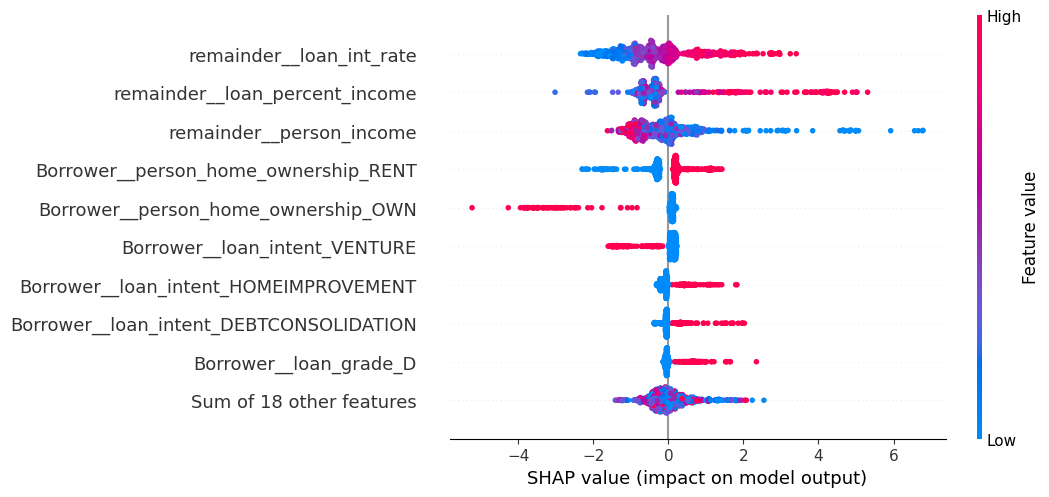

In [142]:
shap.plots.beeswarm(
    shap.Explanation(
        values=shap_values,
        data=x_sample,
        feature_names=feature_names
    )
)

SHAP analysis identified loan interest rate and loan-to-income ratio as the strongest drivers of predictions

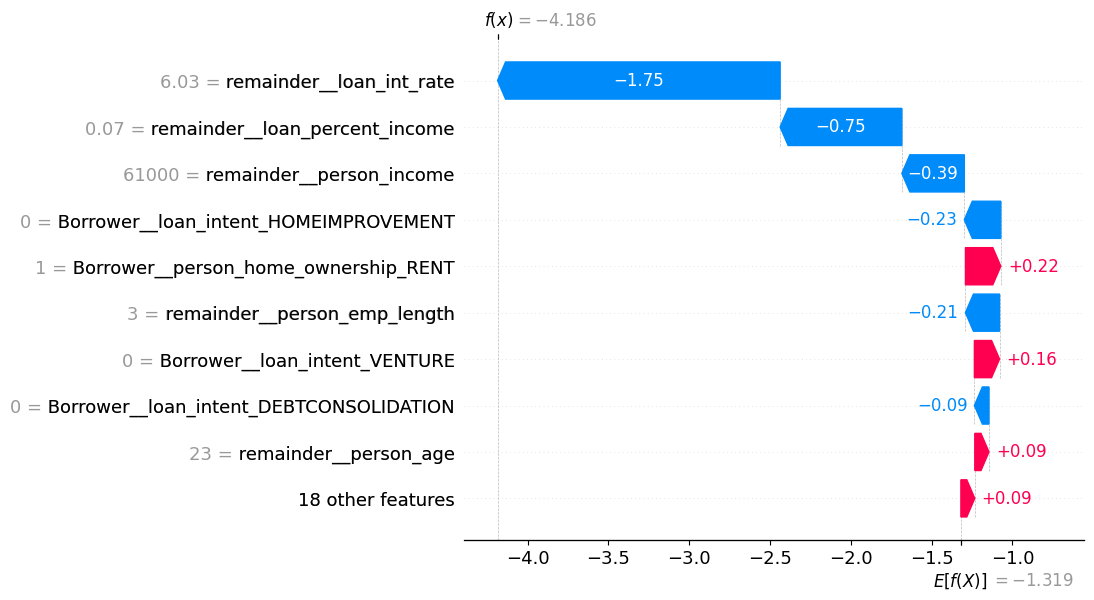

In [145]:
explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=x_sample,
    feature_names=feature_names
)
shap.plots.waterfall(explanation[0])

In [146]:
# XGBoost Feature Importance
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    'Importance',
    ascending=False
)

importance_df.head(15)

,Feature,Importance
3,Borrower__person_home_ownership_RENT,0.202457
24,remainder__loan_percent_income,0.155106
12,Borrower__loan_grade_C,0.091352
23,remainder__loan_int_rate,0.085203
4,Borrower__loan_intent_DEBTCONSOLIDATION,0.059266
7,Borrower__loan_intent_MEDICAL,0.052649
13,Borrower__loan_grade_D,0.043671
6,Borrower__loan_intent_HOMEIMPROVEMENT,0.043200
2,Borrower__person_home_ownership_OWN,0.036102
20,remainder__person_income,0.033597


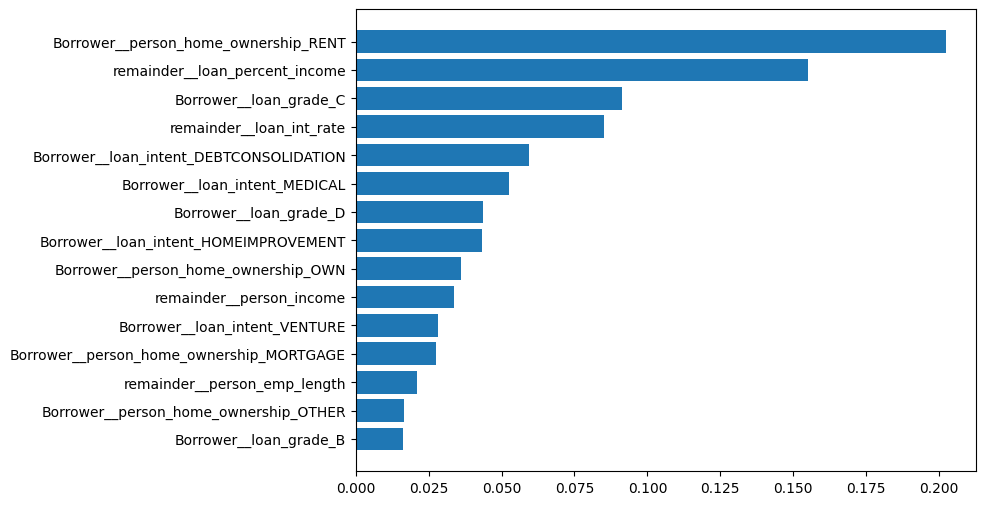

In [147]:
import matplotlib.pyplot as plt

top15 = importance_df.head(15)

plt.figure(figsize=(8,6))
plt.barh(top15['Feature'], top15['Importance'])
plt.gca().invert_yaxis()
plt.show()

Saving the model

In [153]:
# compairing model summary
results = pd.DataFrame({
    'Model':['Logistic Regression','Random Forest','XGBoost'],
    'Recall':[0.56,0.72,0.72],
    'F1':[0.64,0.82,0.83],
    'ROC_AUC':[0.867,0.933,0.942]
})

results

,Model,Recall,F1,ROC_AUC
0,Logistic Regression,0.56,0.64,0.867
1,Random Forest,0.72,0.82,0.933
2,XGBoost,0.72,0.83,0.942


In [154]:
import joblib

joblib.dump(xgb, 'xgboost_model.pkl')

['xgboost_model.pkl']

In [155]:
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']